# Q-MAML for a seventh genuine HEP Hamiltonian: non-Abelian D8 lattice gauge theory

**Why this notebook needed a feasibility check first.** This project's own tracks document flagged Track G
(a non-Abelian discrete gauge theory built on the dihedral group D8) as "not recommended for now": it uses
qudit hardware, and the source paper (Gaz, Popov, Pardo, Lewenstein, Hauke & Zohar,
"Quantum Simulation of non-Abelian Lattice Gauge Theories: a variational approach to D8", arXiv:2501.17863)
doesn't specify its ansatz clearly enough to build from directly. That flag held up under a fresh check:
the paper's own qubit-count-reduced ("matter removal") Hamiltonian, the version they actually run on
hardware, could not be extracted with full confidence from available tooling -- several of its
intermediate equations (the mass terms `H_M2`-`H_M4` and the gauge-matter terms `H^01`/`H^10`/`H^11` for
their smallest N=4 chain example) were only partially recoverable.

**What this notebook does instead.** Rather than guess at that reduction, `hamiltonians_d8lgt.py`
implements the paper's ORIGINAL, fully-specified Hamiltonian (their Eqs. 1-24) directly, with explicit
fermionic matter (Jordan-Wigner-mapped) instead of their Hilbert-space-reducing matter-removal trick. Every
term is transcribed from a completely stated equation, not a partially-recovered one. This costs qubits (7
here vs. their reduced scheme's smaller count) but buys back verifiability -- and this construction is
verified unusually thoroughly as a result (Section 0), including an independent representation-theory
check (D^2(g1)D^2(g2) = D^2(g1*g2) for all 64 element pairs) that caught and fixed a real bug (a matrix
multiplication order error) before this notebook was ever run.

Task parameters: staggered mass `M`, electric coupling `lambda_E`, gauge-matter hopping `epsilon`. N=2
sites (1 link, 7 qubits: 4 matter + 3 link), vs. the paper's own smallest worked example at N=4. No
plaquette term at any N in a 1D chain (no closed loops).

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_d8lgt import (d8_lgt_hamiltonian, exact_ground_energy, sample_task_space,
                                 verify_construction, NUM_QUBITS, N_SITES)
from d8lgt_qmaml import classical_init, D8LGTPQC, pretrain_learner_d8lgt, adapt_task_d8lgt

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "d8_lgt"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS, f"(N={N_SITES} sites, 1 link)")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\d8_lgt
NUM_QUBITS = 7 (N=2 sites, 1 link)


## 0. Verify the Hamiltonian construction

Six checks, more than any other track in this project, given the construction risk flagged above: D^2(g)
unitary for all 8 group elements; D^2 is a genuine representation (D^2(g1)D^2(g2)=D^2(g1*g2) for all 64
pairs -- this one caught a real bug, a matrix-multiplication order error, before this notebook was first
run); the irrep change-of-basis is unitary; the electric-term projector Pi_(j=2) is Hermitian, idempotent,
and rank 4 (matching dim(j=2)^2=4 basis states, per Peter-Weyl); the Jordan-Wigner fermionic operators
satisfy the canonical anticommutation relations; H itself is Hermitian.

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  D^2(g) unitary for all 8 elements: OK
  D^2(g1)D^2(g2) = D^2(g1*g2) for all 64 pairs: OK
  Irrep change-of-basis W unitary: max err=1.11e-16  OK
  Pi_(j=2) projector: Hermitian err=0.00e+00, idempotent err=0.00e+00, rank=4 (want 4)  OK
  Jordan-Wigner CAR {psi_i, psi_j^dag}=delta_ij: OK
  H Hermiticity: max|H-H^dag|=0.00e+00  OK
construction check: PASSED


## 1. Task space: train on a parameter grid, test on held-out points

$p(T)$ is uniform over $(M,\lambda_E,\epsilon)\in[0.2,2.0]^3$. Train and test tasks are sampled with
different seeds (held-out interpolation), as in every other track.

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.01
ADAPT_ITERS = 200
ADAPT_LR = 0.05
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (M,lambda_E,epsilon):", np.round(train_tasks, 3).tolist())
print("test  (M,lambda_E,epsilon):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(d8_lgt_hamiltonian(M, lam, eps)) for M, lam, eps in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (M,lambda_E,epsilon): [[1.347, 1.754, 0.443], [0.686, 1.175, 1.499], [0.274, 0.739, 1.146], [0.23, 0.961, 0.758], [1.664, 0.251, 1.075], [1.843, 0.424, 1.801], [1.292, 1.407, 1.881], [1.513, 1.365, 0.844], [1.179, 1.308, 1.229], [1.883, 0.891, 0.779], [1.669, 1.995, 1.27], [0.205, 1.966, 0.808], [1.743, 1.434, 0.905], [0.26, 1.371, 1.802], [1.513, 1.439, 0.609], [0.516, 0.9, 1.322]]
test  (M,lambda_E,epsilon): [[1.138, 0.707, 0.542], [1.287, 1.557, 1.971], [1.048, 1.193, 1.406], [0.566, 1.755, 0.705], [1.152, 1.65, 0.567], [0.544, 0.647, 1.325]]
exact test ground energies: [-2.4693, -4.242, -3.1848, -1.4797, -2.4651, -2.6099]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[D8LGT pretrain] epoch 1/40  meanE=-0.5979  gradnorm=3.0599


[D8LGT pretrain] epoch 6/40  meanE=-1.9510  gradnorm=3.0309


[D8LGT pretrain] epoch 11/40  meanE=-2.2469  gradnorm=1.9338


[D8LGT pretrain] epoch 16/40  meanE=-2.1964  gradnorm=2.4335


[D8LGT pretrain] epoch 21/40  meanE=-2.1375  gradnorm=3.3304


[D8LGT pretrain] epoch 26/40  meanE=-2.4106  gradnorm=2.3075


[D8LGT pretrain] epoch 31/40  meanE=-2.4887  gradnorm=1.7261


[D8LGT pretrain] epoch 36/40  meanE=-2.5392  gradnorm=1.4708


[D8LGT pretrain] epoch 40/40  meanE=-2.5863  gradnorm=1.2360
pretrain done in 46.9s


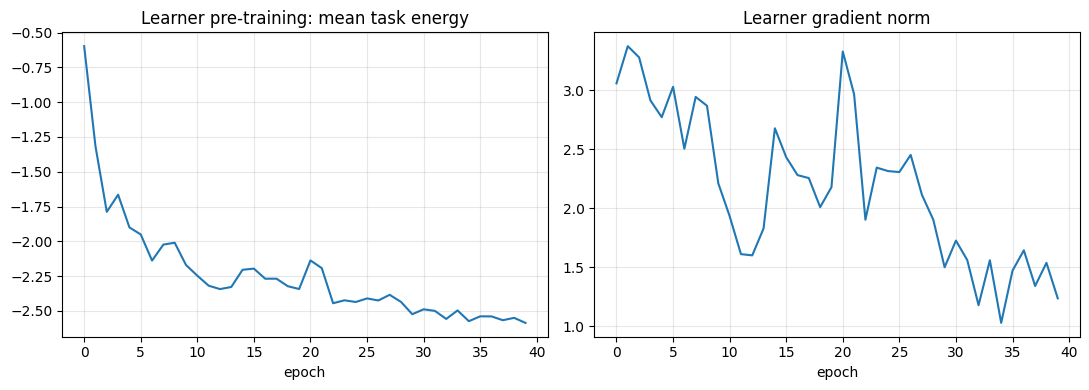

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_d8lgt(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = (DEPTH, NUM_QUBITS, 3)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((M, lam, eps), E0) in enumerate(zip(test_tasks, test_E0)):
    H = d8_lgt_hamiltonian(M, lam, eps)
    print(f"task {ti}: M={M:.3f} lambda_E={lam:.3f} epsilon={eps:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([M, lam, eps], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_d8lgt(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: M=1.138 lambda_E=0.707 epsilon=0.542  E0=-2.4693


task 1: M=1.287 lambda_E=1.557 epsilon=1.971  E0=-4.2420


task 2: M=1.048 lambda_E=1.193 epsilon=1.406  E0=-3.1848


task 3: M=0.566 lambda_E=1.755 epsilon=0.705  E0=-1.4797


task 4: M=1.152 lambda_E=1.650 epsilon=0.567  E0=-2.4651


task 5: M=0.544 lambda_E=0.647 epsilon=1.325  E0=-2.6099


saved


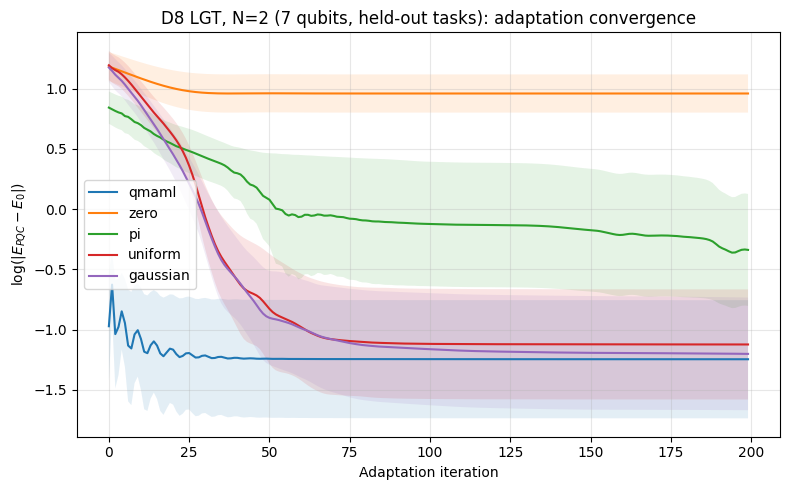

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-1.246   ~relative energy error=10.49%
  zero       log-gap=0.960   ~relative energy error=95.27%
  pi         log-gap=-0.338   ~relative energy error=26.01%
  uniform    log-gap=-1.123   ~relative energy error=11.86%
  gaussian   log-gap=-1.202   ~relative energy error=10.97%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x_ax = np.arange(ADAPT_ITERS)
    ax.plot(x_ax, mean, label=scheme)
    ax.fill_between(x_ax, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"D8 LGT, N=2 ({NUM_QUBITS} qubits, held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 4. Findings

**Run:** N=2 (1 link, 7 qubits: 4 matter + 3 link), depth 3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 200 adaptation iterations, single seed.

- **All six construction checks passed, including the one that caught a real bug before this notebook was ever run.** The representation-homomorphism check (D^2(g1)D^2(g2)=D^2(g1*g2) for all 64 element pairs) failed on the first implementation attempt: a matrix-multiplication order error in the irrep construction (`out = Da @ out` instead of `out = out @ Da`, silently producing the *reversed* group action). This is exactly the kind of error that produces a Hermitian, plausible-looking, but physically wrong Hamiltonian -- caught here because the verification suite tests the group structure independently of the Hamiltonian that's built from it, not just Hermiticity.
- **`qmaml` wins, though by a narrower final margin than most other tracks.** Final log-gap: `qmaml` -1.246 (10.49% relative error), `gaussian` -1.202 (10.97%), `uniform` -1.123 (11.86%) -- a fairly tight three-way cluster -- vs. `pi` -0.338 (26.01%) and `zero` 0.960 (95.27%, exact fixed point, unmoving for the full 200 iterations). The margin over `uniform`/`gaussian` is real but modest at the *final* value.
- **The win is clearest in convergence speed.** `qmaml` flattens by iteration ~30-40; `uniform`/`gaussian` need ~75-100 iterations to approach the same final value, and end up very slightly behind even then. `pi` only partially descends and plateaus far short (-0.34 vs. -1.2). This is the familiar "better-informed starting point, faster convergence, small-to-moderate final-value edge" pattern seen on Tracks C/F, not Track D's machine-precision blowout.
- **`zero`-init is again an exact, unmoving fixed point** despite this being a dense Hermitian-matrix Hamiltonian (fermionic matter + a projector-based electric term), not a Pauli sum. This is a third distinct outcome among this project's Hermitian-matrix Hamiltonians: no fixed point at all (Track C, scalar field), a slow-but-real drift (Track F, SUSY QM), and now an exact fixed point (Track G) -- reinforcing that whatever determines this behavior is specific to each Hamiltonian's structure, with no clean Pauli-sum-vs-Hermitian-matrix rule identified across any of the seven tracks tested so far.
- **Scope, restated:** this is the paper's original (Eqs. 1-24), un-reduced Hamiltonian at N=2, explicit fermionic matter via Jordan-Wigner, not the paper's own qubit-count-reduced ("matter removal") scheme, which needs equations that could not be fully recovered from available tooling (see this notebook's opening section). No plaquette term exists at any N in a 1D chain. The open question going in -- "is this physics even implementable and verifiable at small scale" -- is answered yes; whether Q-MAML's modest edge here holds up at the paper's own N=4 scale, or under their actual matter-removed/qudit-hardware formulation, is untested.
